In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Apply the project styling rule from Step 5.2
plt.rcParams.update({
    "figure.facecolor": "#F8F5EF",
    "axes.facecolor": "#F8F5EF",
    "axes.edgecolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "xtick.color": "#2B2B2B",
    "ytick.color": "#2B2B2B",
    "grid.color": "#DCD5C9",
})

# 2. Load the dataset into memory safely (from PART 4)
cols = ["cord_uid", "title", "abstract", "publish_time",
        "authors", "journal", "license", "doi", "source_x"]

dtypes = {
    "cord_uid": "string",
    "title": "string",
    "abstract": "string",
    "authors": "string",
    "journal": "string",
    "license": "category",
    "doi": "string",
    "source_x": "category",
}

df = pd.read_csv("../data/metadata.csv", usecols=cols, dtype=dtypes, low_memory=False)
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
df = df.dropna(subset=["abstract"])

In [2]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_abstract"] = df["abstract"].apply(clean_text)

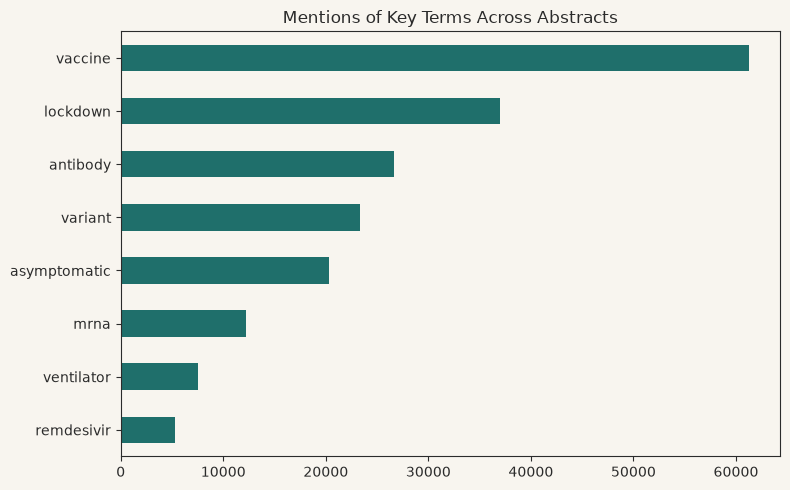

In [3]:
keywords = ["vaccine", "remdesivir", "ventilator", "asymptomatic",
            "variant", "lockdown", "mrna", "antibody"]

for kw in keywords:
    df[f"has_{kw}"] = df["clean_abstract"].str.contains(kw)

kw_counts = pd.Series({kw: df[f"has_{kw}"].sum() for kw in keywords}).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
kw_counts.plot(kind="barh", color="#1F6F6B", ax=ax)
ax.set_title("Mentions of Key Terms Across Abstracts")
plt.tight_layout()
plt.savefig("../figures/keyword_mentions.png", dpi=150)

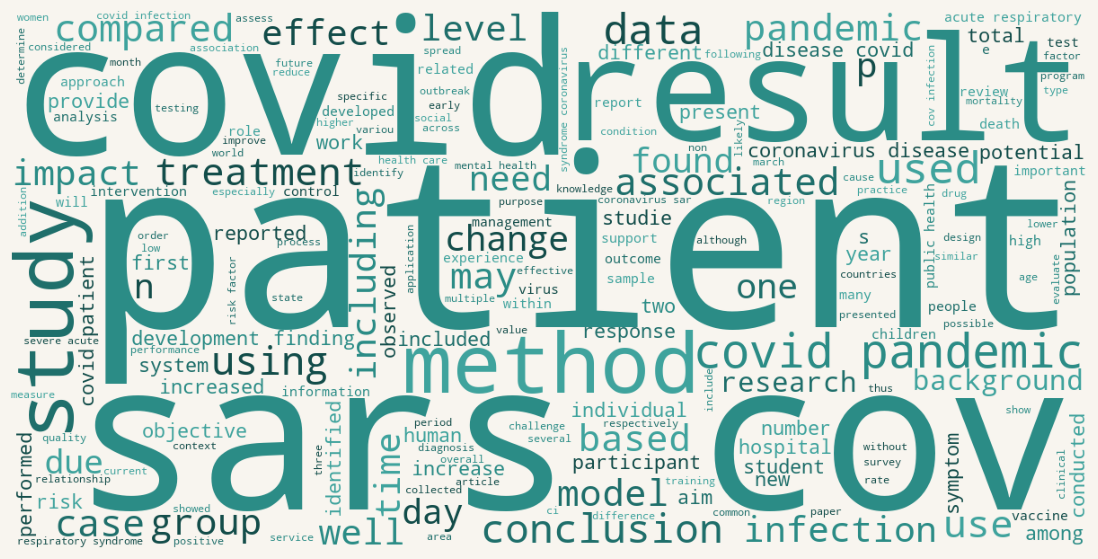

In [4]:
from wordcloud import WordCloud, STOPWORDS

def teal_shades(word, font_size, position, orientation, random_state=None, **kwargs):
    import random
    shades = ["#1F6F6B", "#2B8C86", "#134D4A", "#3FA39D"]
    return random.choice(shades)

sample_text = " ".join(df["clean_abstract"].dropna().sample(20000, random_state=42))
wc = WordCloud(width=1200, height=600, background_color="#F8F5EF",
               stopwords=STOPWORDS, color_func=teal_shades).generate(sample_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc)
plt.axis("off")
plt.savefig("../figures/wordcloud.png", dpi=150, facecolor="#F8F5EF")